# 焊接工艺参数数据库 — 探索与可视化

数据源: `project_data/data/Welding Process Parameter Database 2022_rev.2022.03.24.xlsx` (2022-03-24 修订)。

这是一份来自实际生产现场的 GMAW/MIG 焊接工艺参数数据库, 按"焊接记录 → 焊道"两级组织:
每条**记录**对应一个工件/接头的工艺规程 (设备、母材、坡口、位置等), 其下多行对应多道焊的**各焊道**参数 (电流、电压、速度、摆动)。

本 notebook 解析并可视化该数据库, 并总结其与本仿真包各模块的对应关系
(电弧自调节 `GMAWDynamics`、Goldak 热源 `GoldakFDM`、摆动/熔滴模块等)。


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

DATA = Path("../project_data/data/Welding Process Parameter Database 2022_rev.2022.03.24.xlsx")
assert DATA.exists(), "请从仓库根目录的 notebooks/ 下运行"

# 中文字体 (环境自带 Noto Sans CJK)
matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 分类色板 (已通过 CVD/对比度校验的参考色板, 按固定顺序取用, 不循环)
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, INK2, MUTED, GRID, BASE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

## 1. 工作簿总览

8 个工作表: 主表 **焊接工艺参数** 存全部记录; **摆动库参数** 是按路点定义的摆动波形库;
**起弧/焊接/收弧/回烧文件** 是各品牌焊机下发文件的参数清单 (勾选"是否每次更新"); **备注** 是录入规则说明。


In [2]:
xls = pd.ExcelFile(DATA)
sheets = {name: xls.parse(name, header=None) for name in xls.sheet_names}
pd.DataFrame({"行数": {k: v.shape[0] for k, v in sheets.items()},
              "列数": {k: v.shape[1] for k, v in sheets.items()}}).rename_axis("工作表")

,行数,列数
工作表,,
焊接工艺参数,421,54
多道焊参数,2,22
起弧文件,34,5
焊接文件,4,3
收弧文件,14,3
回烧文件,6,3
摆动库参数,106,10
备注,12,1


## 2. 主表解析: 记录 ↔ 焊道 两级结构

主表前 3 行是多级表头, 第 4 行是填写说明, 数据从第 5 行起。
记录级字段 (设备、母材、坡口……) 使用了合并单元格 — 读入后只有每条记录的首行有值, 需**前向填充**;
`道号` 逐行给出 (0 = 单道焊)。

数值字段格式不一, 解析规则:
- **电流**: 林肯焊机填 "送丝设定(实际电流A)" 如 `420（280A）` → 取括号内实际电流; 双丝工艺 `227A(主…)/210A(从…)` → 取主丝; 区间取中值; 无括号的纯数直接取用 (>450 者多为送丝设定, 后续按合理窗口过滤)。
  该规则与"备注"表第 11 条一致: *林肯焊机控制送丝速度 (in/min), 伏能士控制送丝速度 (m/min), 其它焊机控制电流 (A)*。
- **电压**: 去掉单位 V; `一元化` (一元化/协同模式, 无独立电压设定) 记为缺失; 双丝取主丝。
- **速度 / 摆动频率、幅值**: 取首个数值。
- **道数** (备注第 12 条): 单道焊写 1; 多道焊根道写 0, 盖面道从 1 起。


In [3]:
raw = sheets["焊接工艺参数"]
COLS = {0: "焊机型号", 1: "母材", 2: "焊丝直径", 3: "焊丝种类", 4: "保护气体",
        5: "焊缝形式", 7: "坡口尺寸", 9: "焊接位置", 10: "焊脚尺寸",
        11: "RX倾斜角", 12: "RY前进角", 14: "道号",
        28: "电流_原始", 29: "电压_原始", 41: "摆动频率_原始", 42: "摆动幅值_原始",
        44: "焊接速度_原始", 45: "客户", 49: "工件名称", 52: "录入日期"}
df = raw.iloc[4:].reset_index(drop=True).rename(columns=COLS)

REC_COLS = list(range(0, 14)) + list(range(45, 54))  # 记录级列 (合并单元格)
df["记录号"] = df["焊机型号"].notna().cumsum()
for c in df.columns:
    if isinstance(c, str) and c in [COLS.get(i) for i in REC_COLS] or c in REC_COLS:
        df[c] = df[c].ffill()

NUM = re.compile(r"\d+(?:\.\d+)?")

def parse_current(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().replace("（", "(").replace("）", ")")
    if not s or s == "*": return np.nan
    m = re.search(r"\(([\d.]+)\s*A?\s*\)", s)      # 括号内 = 实际电流
    if m and float(m.group(1)) >= 50: return float(m.group(1))
    m = NUM.search(s.split("/")[0])                     # 双丝取主丝
    if not m: return np.nan
    x = float(m.group(0))
    m2 = re.search(r"-\s*([\d.]+)", s.split("(")[0])  # 区间取中值
    if m2 and float(m2.group(1)) > x: x = (x + float(m2.group(1))) / 2
    return x

def parse_num(v):
    if pd.isna(v): return np.nan
    m = NUM.search(str(v).strip().replace("（", "(").split("/")[0])
    return float(m.group(0)) if m else np.nan

df["电流A"] = df["电流_原始"].map(parse_current)
df["电压V"] = df["电压_原始"].map(parse_num)
df.loc[df["电压_原始"].astype(str).str.contains("一元化", na=False), "电压V"] = np.nan
df["速度mm/s"] = df["焊接速度_原始"].map(parse_num)
df["摆频Hz"] = df["摆动频率_原始"].map(parse_num)
df["摆幅mm"] = df["摆动幅值_原始"].map(parse_num)
df["焊丝直径mm"] = pd.to_numeric(df["焊丝直径"], errors="coerce")

rec = df.groupby("记录号").first()
rec["焊道数"] = df.groupby("记录号").size()

print(f"记录数: {len(rec)}   焊道行数: {len(df)}")
print("每条记录的焊道数分布:")
print(rec["焊道数"].value_counts().sort_index().to_string())
rec[["焊机型号", "母材", "焊丝直径", "保护气体", "焊缝形式", "焊接位置", "焊道数", "客户"]].head(8)

记录数: 130   焊道行数: 417
每条记录的焊道数分布:
焊道数
1     55
2     12
3     13
4     13
5      4
6     14
7     13
8      4
10     2


,焊机型号,母材,焊丝直径,保护气体,焊缝形式,焊接位置,焊道数,客户
记录号,,,,,,,,
1,林肯R450,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,3,三一重装
2,林肯R450,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,4,三一重装
3,林肯R450,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,4,三一重装
4,林肯R450,碳钢,1.2,82% Ar + 18% CO2,角接,平角焊,7,三一重装
5,林肯R450,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,4,三一重装
6,林肯R450,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,4,三一重装
7,林肯R450,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,5,三一重装
8,林肯R450,碳钢,1.2,82% Ar + 18% CO2,单V坡口,平焊,5,三一重装


## 3. 设备与工况分布 (记录级)

品牌型号写法不统一 (如 "林肯R450" / "林肯450", "福尼斯" 与 "伏能士" 均为 Fronius 的音译), 先归一到厂商级再统计。


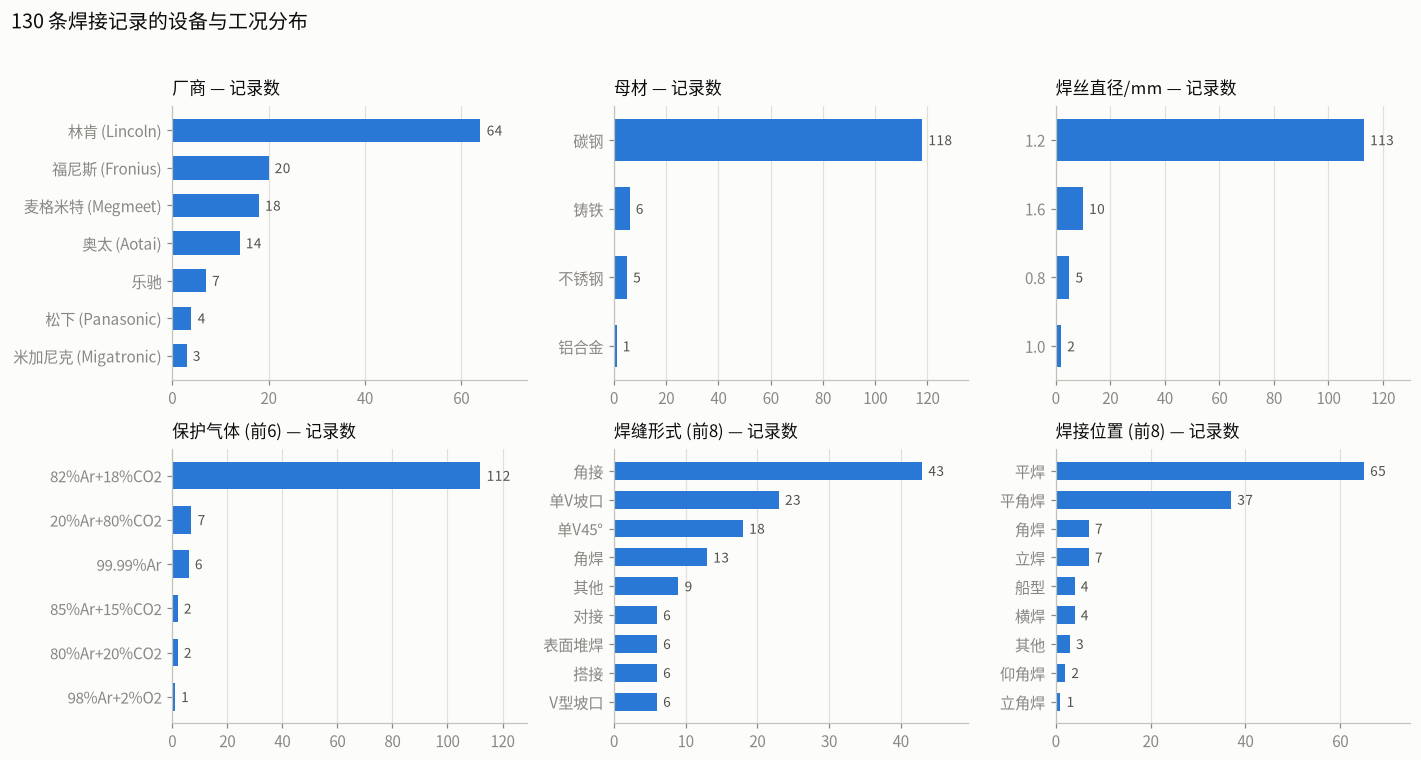

In [4]:
def manufacturer(s):
    s = str(s)
    for key, name in [("林肯", "林肯 (Lincoln)"), ("奥太", "奥太 (Aotai)"),
                      ("麦格米特", "麦格米特 (Megmeet)"), ("福尼斯", "福尼斯 (Fronius)"),
                      ("伏能士", "福尼斯 (Fronius)"), ("乐驰", "乐驰"), ("乐弛", "乐驰"),
                      ("松下", "松下 (Panasonic)"), ("米加尼克", "米加尼克 (Migatronic)")]:
        if key in s: return name
    return "其他"

rec["厂商"] = rec["焊机型号"].map(manufacturer)
rec["气体"] = rec["保护气体"].astype(str).str.replace("氩气", "Ar").str.replace(" ", "")
rec["焊缝"] = rec["焊缝形式"].astype(str).str.replace("v", "V")

panels = [("厂商", rec["厂商"]), ("母材", rec["母材"]),
          ("焊丝直径/mm", rec["焊丝直径mm"].dropna().map("{:.1f}".format)),
          ("保护气体 (前6)", rec["气体"]), ("焊缝形式 (前8)", rec["焊缝"]), ("焊接位置 (前8)", rec["焊接位置"])]
tops = [99, 99, 99, 6, 8, 8]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, s), top in zip(axes.ravel(), panels, tops):
    vc = s.value_counts()
    if len(vc) > top:
        vc = pd.concat([vc.head(top), pd.Series({"其他": vc.iloc[top:].sum()})])
    vc = vc.sort_values()
    ax.barh(vc.index.astype(str), vc.values, color=C[0], height=0.62)
    for y, v in enumerate(vc.values):
        ax.text(v + max(vc.values) * 0.02, y, str(v), va="center", color=INK2, fontsize=9)
    ax.set_xlim(0, max(vc.values) * 1.15)
    ax.grid(axis="y", visible=False)
    style_ax(ax, title=f"{title} — 记录数")
fig.suptitle("130 条焊接记录的设备与工况分布", color=INK, x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. 工艺窗口: 电流–电压 (焊道级)

每个点是一条焊道。按合理物理窗口过滤 (80–450 A, 10–45 V), 排除送丝设定被误当电流、
以及 `一元化`/CMT 修正值等无法解释为电弧电压的行。

这是电源"一元化/协同"曲线所在的平面 — 与模块 1 `GMAWDynamics` 的恒压特性 + 电弧自调节工作点直接对应。


参与绘图焊道: 365 / 417 (其余为缺失/一元化/无法解析)


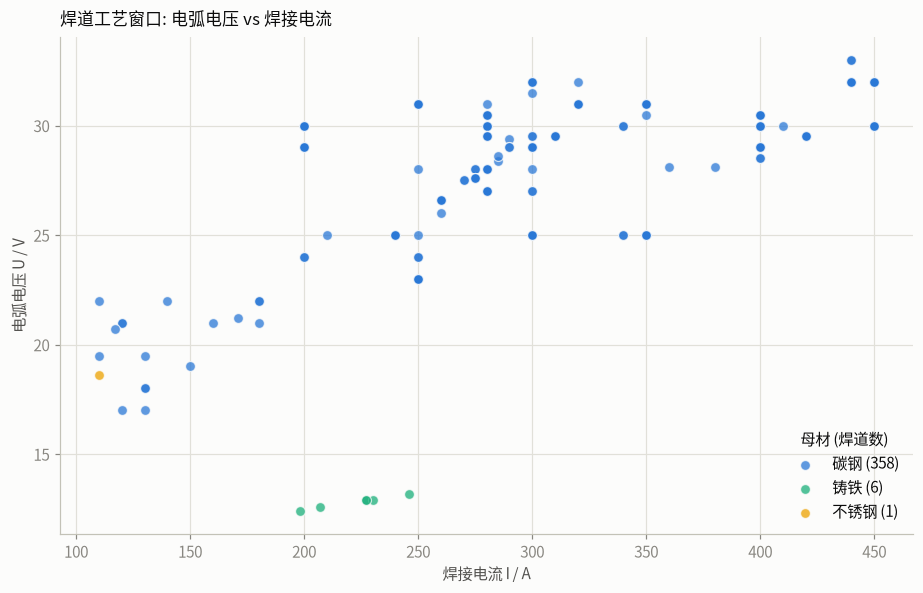

In [5]:
mat_order = rec["母材"].value_counts().index.tolist()
plaus = df[(df["电流A"].between(80, 450)) & (df["电压V"].between(10, 45))].copy()
plaus = plaus.join(rec["母材"].rename("母材_rec"), on="记录号")
print(f"参与绘图焊道: {len(plaus)} / {len(df)} (其余为缺失/一元化/无法解析)")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i, m in enumerate(mat_order):
    g = plaus[plaus["母材_rec"] == m]
    if g.empty: continue
    ax.scatter(g["电流A"], g["电压V"], s=42, color=C[i], alpha=0.75,
               edgecolors="#fcfcfb", linewidths=0.8, label=f"{m} ({len(g)})")
ax.legend(title="母材 (焊道数)", frameon=False, loc="lower right")
style_ax(ax, title="焊道工艺窗口: 电弧电压 vs 焊接电流", xlabel="焊接电流 I / A", ylabel="电弧电压 U / V")
fig.tight_layout()
plt.show()

## 5. 焊接速度与线热输入

线热输入 $E = U \cdot I / v$ (kJ/mm, 未乘电弧效率; GMAW 典型 $\eta \approx 0.8$)。
$\eta U I$ 正是模块 4 `GoldakFDM` 双椭球热源的输入功率, $v$ 是热源移动速度 —
下面的分布给出了驱动热场仿真的**现实参数范围**。


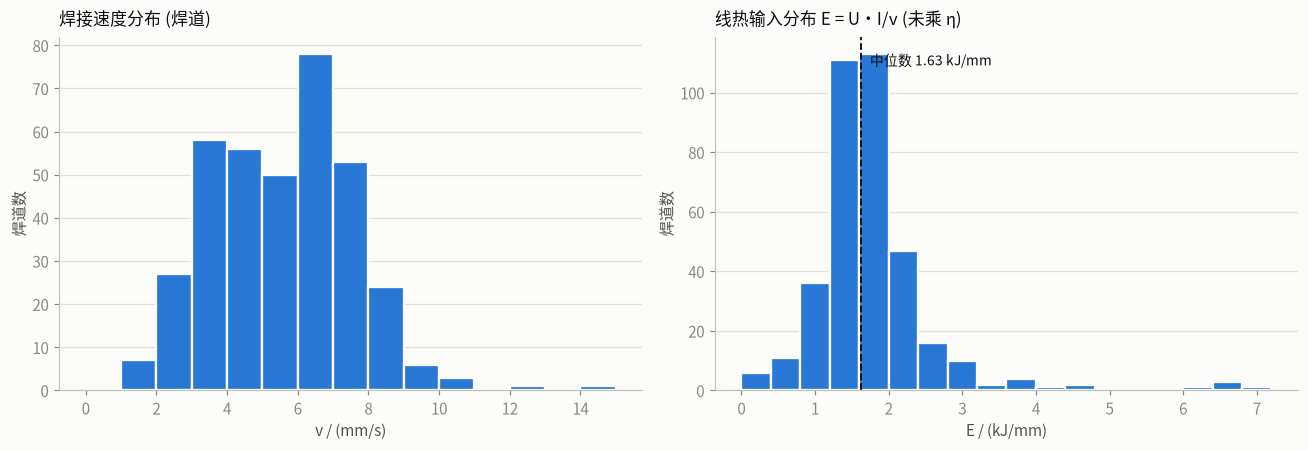

I: 110–450 A   U: 12.4–33.0 V   v: 1.1–15.0 mm/s   E 中位数: 1.63 kJ/mm (P10–P90: 1.00–2.48)


In [6]:
plaus["热输入kJ/mm"] = plaus["电压V"] * plaus["电流A"] / plaus["速度mm/s"] / 1000
E = plaus["热输入kJ/mm"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(plaus["速度mm/s"].dropna(), bins=np.arange(0, 16, 1), color=C[0],
             edgecolor="#fcfcfb", linewidth=1.5)
style_ax(axes[0], title="焊接速度分布 (焊道)", xlabel="v / (mm/s)", ylabel="焊道数")

axes[1].hist(E, bins=np.arange(0, 7.5, 0.4), color=C[0], edgecolor="#fcfcfb", linewidth=1.5)
axes[1].axvline(E.median(), color=INK, linewidth=1.2, linestyle="--")
axes[1].text(E.median() + 0.12, axes[1].get_ylim()[1] * 0.92,
             f"中位数 {E.median():.2f} kJ/mm", color=INK, fontsize=9)
style_ax(axes[1], title="线热输入分布 E = U·I/v (未乘 η)", xlabel="E / (kJ/mm)", ylabel="焊道数")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()
print(f"I: {plaus['电流A'].min():.0f}–{plaus['电流A'].max():.0f} A   "
      f"U: {plaus['电压V'].min():.1f}–{plaus['电压V'].max():.1f} V   "
      f"v: {plaus['速度mm/s'].min():.1f}–{plaus['速度mm/s'].max():.1f} mm/s   "
      f"E 中位数: {E.median():.2f} kJ/mm (P10–P90: {E.quantile(.1):.2f}–{E.quantile(.9):.2f})")

## 6. 摆动参数 (焊道级)

摆动在生产数据中非常普遍。点的大小 = 使用该 (频率, 幅值) 组合的焊道数
(参数取值高度离散, 直接散点会完全重叠)。


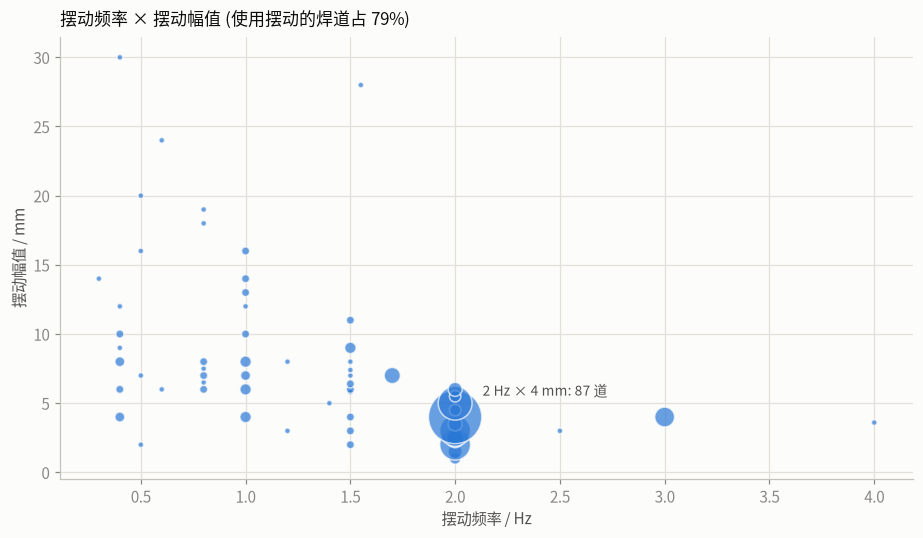

In [7]:
w = df[(df["摆频Hz"] > 0) & (df["摆幅mm"] > 0)]
share = len(w) / df["摆幅mm"].notna().sum()
grp = w.groupby(["摆频Hz", "摆幅mm"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(grp["摆频Hz"], grp["摆幅mm"], s=grp["n"] * 14, color=C[0], alpha=0.7,
           edgecolors="#fcfcfb", linewidths=1)
big = grp.nlargest(1, "n").iloc[0]
ax.annotate(f"{big['摆频Hz']:g} Hz × {big['摆幅mm']:g} mm: {big['n']:.0f} 道",
            (big["摆频Hz"], big["摆幅mm"]), textcoords="offset points",
            xytext=(18, 14), color=INK2, fontsize=9)
style_ax(ax, title=f"摆动频率 × 摆动幅值 (使用摆动的焊道占 {share:.0%})",
         xlabel="摆动频率 / Hz", ylabel="摆动幅值 / mm")
fig.tight_layout()
plt.show()

## 7. 摆动库: 路点波形

`摆动库参数` 表用一个周期内的路点定义摆动波形: 时间为周期百分比, X/Y/Z 为幅值百分比
(Y 横向、Z 垂直), 另有角度与电流/电压调制列 (本库中全为 0)。下面重建前 12 个编号的波形。


摆动波形共 21 个, 编号: [107, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


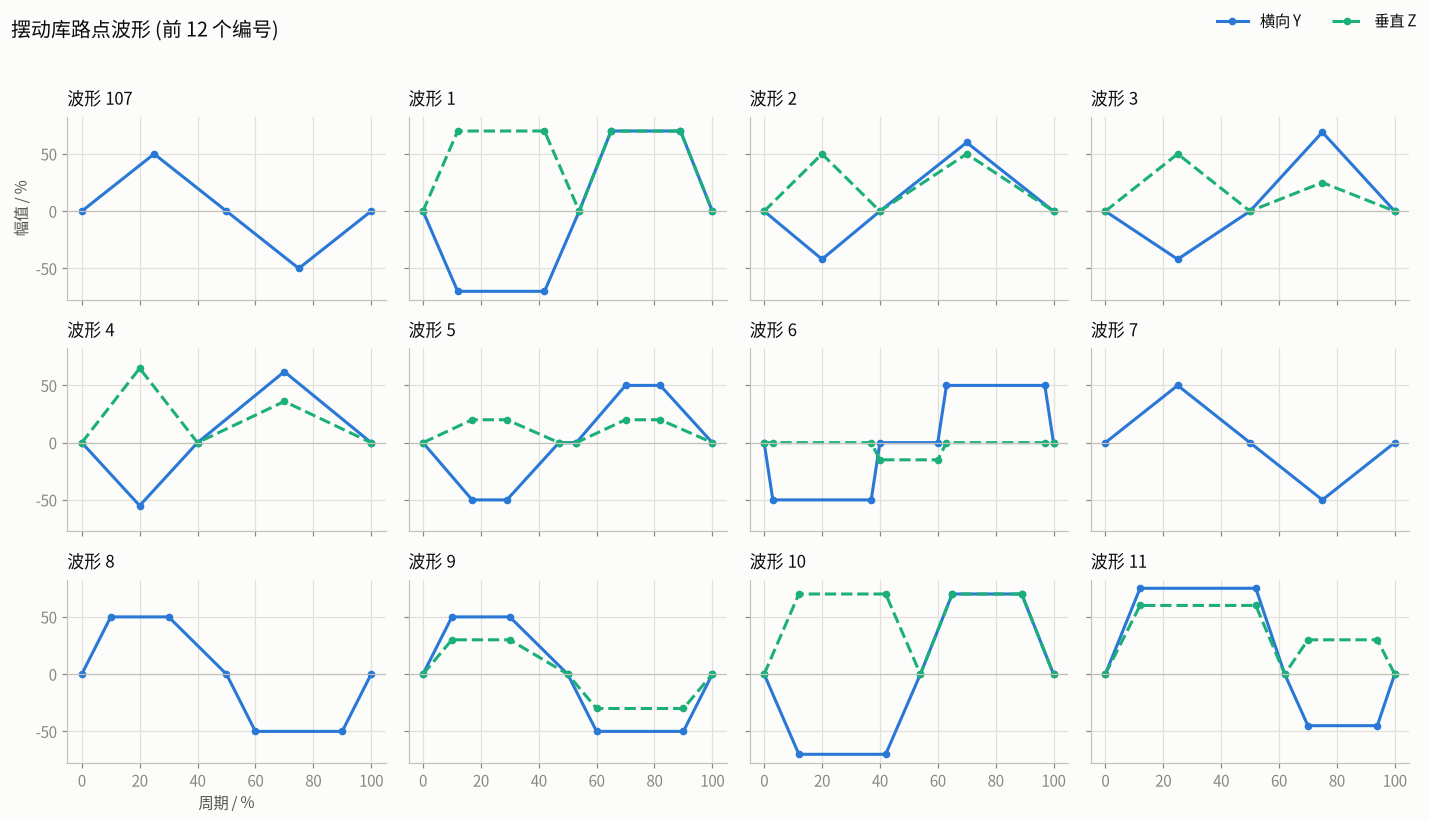

In [8]:
wl = sheets["摆动库参数"].iloc[1:, :10].copy()
wl.columns = ["编号", "点", "时间%", "X%", "Y%", "Z%", "角度", "电流%", "电压%", "更新"]
wl["编号"] = wl["编号"].ffill()
wl = wl.dropna(subset=["点"])
for c in ["时间%", "X%", "Y%", "Z%"]:
    wl[c] = pd.to_numeric(wl[c], errors="coerce")
ids = wl["编号"].unique()
print(f"摆动波形共 {len(ids)} 个, 编号: {list(ids)}")

show = ids[:12]
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, pid in zip(axes.ravel(), show):
    g = wl[wl["编号"] == pid].sort_values("时间%")
    t = np.r_[0, g["时间%"].values, 100]           # 闭合一个周期 (起点/终点回到 0)
    y = np.r_[0, g["Y%"].values, 0]
    z = np.r_[0, g["Z%"].values, 0]
    ax.plot(t, y, color=C[0], linewidth=2, marker="o", markersize=4)
    if np.abs(z).max() > 0:
        ax.plot(t, z, color=C[1], linewidth=2, marker="o", markersize=4, linestyle="--")
    ax.axhline(0, color=BASE, linewidth=0.8)
    style_ax(ax, title=f"波形 {pid:g}")
axes[0, 0].set_ylabel("幅值 / %")
axes[-1, 0].set_xlabel("周期 / %")
handles = [plt.Line2D([], [], color=C[0], lw=2, marker="o", ms=4, label="横向 Y"),
           plt.Line2D([], [], color=C[1], lw=2, marker="o", ms=4, ls="--", label="垂直 Z")]
fig.legend(handles=handles, loc="upper right", frameon=False, ncols=2)
fig.suptitle("摆动库路点波形 (前 12 个编号)", color=INK, x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 8. 辅助表: 焊机文件参数清单与录入规则

In [9]:
for name in ["起弧文件", "焊接文件", "收弧文件", "回烧文件"]:
    t = sheets[name]
    items = t.iloc[1:, 0].dropna().astype(str).str.strip()
    items = [s.split("：")[0].split("\n")[0][:26] for s in items if s and s != "焊接参数"]
    print(f"{name} ({len(items)} 项): " + "、".join(items))
    print()
print("—— 备注表 (录入规则) ——")
for line in sheets["备注"].iloc[:, 0].dropna():
    print(" ", str(line).strip())

起弧文件 (32 项): 文件号、焊机相关工艺参数、前气时间、起弧时间、过渡时间、暂停时间、焊接条件、使能、检测时间、检测次数、间隔出丝时间、漏弧检测、使能、检测时间、重启/偏移、电弧重启使能、起弧偏移使能、公共参数、偏移速度、返回速度、偏移起弧文件、电弧重启、重启次数、焊枪提升、直线X向偏移、圆弧Y向偏移、抽丝时间、暂停时间、起弧偏移、X向偏移、Y向偏移、Z向偏移

焊接文件 (2 项): 文件号、焊机相关工艺参数

收弧文件 (12 项): 文件号、焊机相关工艺参数、后气时间、收弧时间、过渡时间、暂停时间、抽丝时间、焊接条件、粘丝检测开关、检测次数、粘丝解除时间、延迟检测时间

回烧文件 (4 项): 文件号、模式、Workpoint、回烧时间

—— 备注表 (录入规则) ——
  1、输入信息为工作站信息、焊接设备、焊接材料、焊接方式
  2、输出焊接参数、摆动参数
  3、数据库工艺参数录入数据与用户查询使用数据库界面不同
  4、用户使用界面的输入信息为下拉菜单式
  5、录入数据时，输入、输出信息可复制、剪切、粘贴、插入、删除、查找、替换
  6、缺省用“*”标记
  7、视频、图片命名规则：项目号+工作站名称
  8、老版摆摆弧摆动形式标注为直线摆（老版摆摆弧摆动仅支持直线摆），新版摆弧摆动形式标注为摆动库文件名，具体摆动数据链接到“摆动库”表格中
  9、坡口尺寸/mm：坡口深度*角度；角焊缝无坡口尺寸；对接焊缝板厚*0°
  10、焊脚尺寸：角焊缝焊脚尺寸/mm：直角边*直角边，对接坡口焊缝焊脚尺寸/mm：余高*焊缝宽度
  11、林肯焊机控制送丝速度，单位:in/min；伏能士焊机控制送丝速度，单位:m/min,其它焊机控制电流，单位：A
  12、道数：单位道写1；多道焊：根道写0，覆盖道从1开始写（与多道焊模板对应）


## 9. 总结

**数据库概况** (2022-03 修订, 录入日期 2022-03-21 ~ 03-24):

- **130 条焊接工艺记录 / 417 条焊道**, 来自 32 家客户的真实生产项目; 单道焊记录 55 条 (42%), 多道焊每条最多 10 道 (根道 0 + 盖面道, 备注第 12 条)。
- **设备**: 以林肯 (Lincoln, ~64 条, 约一半) 为主, 其余为奥太、麦格米特、福尼斯/伏能士 (Fronius, 含 CMT 双丝)、乐驰、松下、米加尼克 — 覆盖了模块 5 中 CMT 短路过渡对应的机型。
- **工况高度集中**: 母材 91% 为碳钢 (另有铸铁、不锈钢、铝合金少量); 焊丝直径 87% 为 1.2 mm 实芯; 保护气体 86% 为 82%Ar+18%CO₂; 焊缝以角接/单V坡口、平焊/平角焊为主。
- **工艺窗口** (可解析焊道): I ≈ 110–450 A, U ≈ 12–33 V, v ≈ 1–15 mm/s; 线热输入 E=U·I/v 中位数 ≈ 1.6 kJ/mm (P10–P90 约 1.0–2.5)。少数行电流栏填的是送丝设定 (林肯 Workpoint), 实际电流在括号内; 福尼斯双丝记录含主/从两组值。
- **摆动**: 约 79% 的焊道启用摆动, 典型组合 2 Hz × 4 mm; 摆动库含 21 个路点定义的波形 (三角/梯形/斜锯齿等, 部分带垂直 Z 分量)。
- **辅助表**: 起弧/焊接/收弧/回烧四个"文件"表不是数据, 而是各品牌焊机 (奥太/麦格米特/林肯) 下发工艺文件的参数清单模板; 回烧文件仅林肯焊机使用。

**与仿真包的对应**:

| 数据库字段 | 仿真模块 | 用途 |
|---|---|---|
| 电流/电压/送丝 (含林肯 WFS 设定) | 模块 1 `GMAWDynamics` | 恒压特性工作点、自调节稳态校核 |
| U·I·η 与焊接速度 | 模块 4 `GoldakFDM` / `RosenthalThermal` | 双椭球热源功率与移动速度的现实取值域 |
| 电流范围 110–450 A | 模块 3 `DropletDynamics` | 覆盖滴状→射流过渡区 (current_sweep) |
| CMT/双丝记录 | 模块 5 `ShortCircuitGMAW`、模块 8 `ContactCycleVI` | CMT 模式参数佐证 |
| 摆动频率/幅值 + 摆动库波形 | 脉冲/摆动激励类模块 (如 `DropletOscillatorVI`) | 现实激励频率量级 (0.3–4 Hz, 远低于熔滴共振频率) |

**数据质量提示**: 品牌与坡口写法不统一、电流栏混填送丝设定、电压存在"一元化"文本、
约 13% 焊道无法解析出完整 I/U/v — 若要做回归/查询应先按本 notebook 第 2 节的规则清洗。
